In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
gdf = gpd.read_file("Park_Boundaries/Parks.shp")
gdf.head()

,NAME,PMA_NAME,ADDRESS,PIN,SUBPARCEL,PMA,OWNER,LEASE,MAINT,USE_,...,NAMEFLAG,REVIEW_DAT,AMWOID,SDQL,SE_ANNO_CA,GIS_CREATO,GIS_CRT_DT,GIS_EDITOR,GIS_EDT_DT,geometry
0,DUWAMISH HEAD GREENBELT,Duwamish Head Greenbelt,None,9151600240,1887,451,DPR,N,DPR,GB,...,9,2004-03-31,PROPERTY-DUWFM,QL-D1,None,DPR,2026-05-21,DPR,2026-05-21,"POLYGON ((1258456.125 217555.531, 1258454.75 2..."
1,DUWAMISH HEAD GREENBELT,Duwamish Head Greenbelt,None,9151600290,1897,451,DPR,N,DPR,GB,...,9,2004-03-31,PROPERTY-DUWFM,QL-D1,None,DPR,2026-05-21,DPR,2026-05-21,"POLYGON ((1258318.125 217531.875, 1258316.75 2..."
2,EAST DUWAMISH GREENBELT,East Duwamish GS: I-90,None,3881900100,1153,283,DPR,N,DPR,GB,...,9,2004-04-07,PROPERTY-EDUWI,QL-D1,None,DPR,2026-05-21,DPR,2026-05-21,"POLYGON ((1273876.787 217514.107, 1273875.416 ..."
3,DUWAMISH HEAD GREENBELT,Duwamish Head Greenbelt,None,9275701385,9676,451,DPR,N,DPR,GB,...,9,1998-05-06,PROPERTY-DUWFM,QL-D1,None,DPR,2026-05-21,DPR,2026-05-21,"POLYGON ((1259507.774 217223.494, 1259364.444 ..."
4,EAST DUWAMISH GREENBELT,East Duwamish GS: I-90,None,1498300265,373,283,DPR,N,DPR,GB,...,9,2004-04-07,PROPERTY-EDUWI,QL-D1,None,DPR,2026-05-21,DPR,2026-05-21,"POLYGON ((1273874.241 217402.514, 1273884.236 ..."


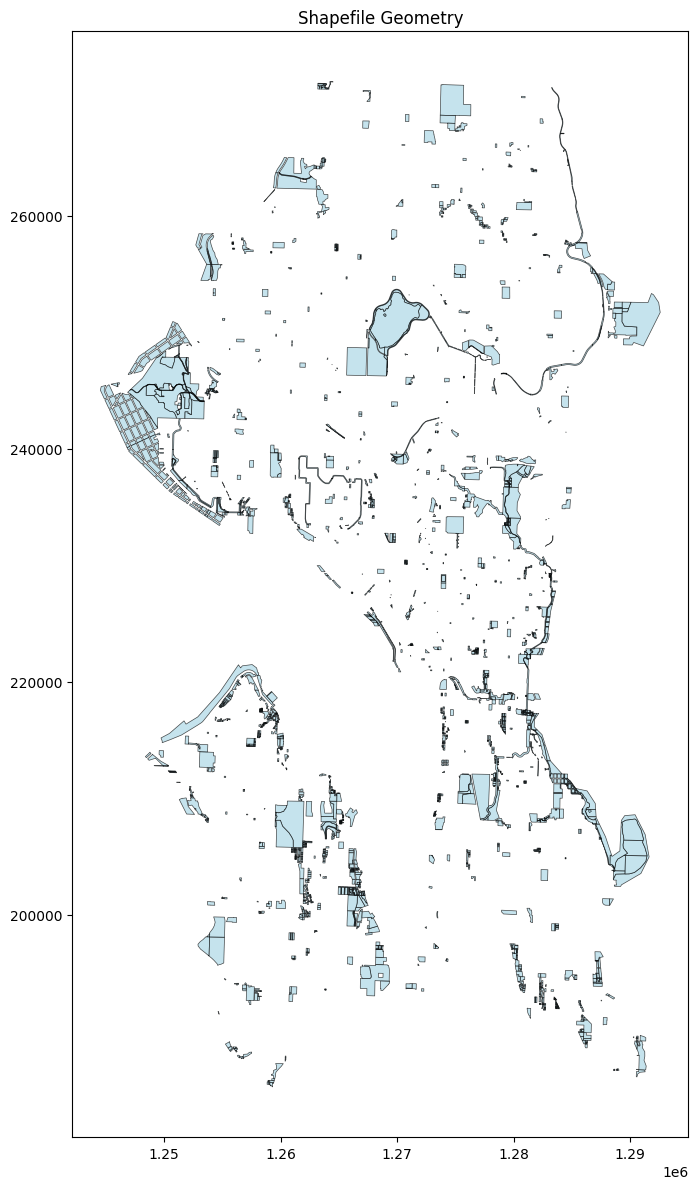

In [5]:
fig, ax = plt.subplots(figsize=(10, 12))

# Split by geometry type
polygons = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]
lines = gdf[gdf.geometry.type.isin(["LineString", "MultiLineString"])]
points = gdf[gdf.geometry.type.isin(["Point", "MultiPoint"])]

# Plot in layers
if not polygons.empty:
    polygons.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.5, alpha=0.7)

if not lines.empty:
    lines.plot(ax=ax, color="black", linewidth=0.8)

if not points.empty:
    points.plot(ax=ax, color="red", markersize=2, alpha=0.5)

plt.title("Shapefile Geometry")
plt.tight_layout()
plt.show()

In [6]:
import requests
import json
import pandas as pd

df = pd.read_csv("Seattle_Parks_And_Recreation_Park_Addresses_20260520.csv")

def search_park(api_key,name):
    """get park ratings"""

    #search text query endpoint
    url = "https://places.googleapis.com/v1/places:searchText"

    #define headers to use in API request
    headers = {
        "Content-Type": "application/json",
        "X-Goog-Api-Key": api_key,
        "X-Goog-FieldMask": "places.displayName,places.rating,places.editorialSummary"
    }
    
    data = {
        "textQuery": f"{name}, Seattle"
    }
    
    #make API request 
    response = requests.post(url, headers=headers, json=data)


    #error handling
    if response.status_code != 200:
        print(f"Error for {name}: {response.text}")
        return None

    #retrieve results
    result = response.json()
    parks = result.get("places", [])

    if not parks:
        print(f"No results for {name}")
        return None
    
    parks = parks[0]

    #append results
    df_data = [{   
       "name": parks.get("displayName", {}).get("text", "N/A"),
       "rating": parks.get("rating", None),
       "summary": parks.get("editorialSummary", {}).get("text", None),
       }]

    df = pd.DataFrame(df_data)
    return df


In [ ]:
#commented out to avoid repeated API calls 

'''import os
from google.cloud import secretmanager

def get_secret(project_id: str, secret_id: str) -> str:
    client = secretmanager.SecretManagerServiceClient()
    name = f"projects/{project_id}/secrets/{secret_id}/versions/latest"
    response = client.access_secret_version(request={"name": name})
    return response.payload.data.decode("utf-8")

PROJECT_ID = os.environ.get("GCP_PROJECT_ID", "grounded-camera-449000-f8")
api_key = get_secret(PROJECT_ID, "GOOGLE_API_KEY")
combined_park_df = pd.DataFrame()
for name in df["Name"]:
    park_info = search_park(api_key, name)
    if park_info is not None:
        
        combined_park_df = pd.concat([combined_park_df, park_info], ignore_index=True)


combined_park_df = combined_park_df.rename(columns={"name":"API_park_name"})
combined_park_df.head(50)

final_df = pd.concat([df, api_df], axis=1)
final_df.head()

final_df.to_csv("parks_with_ratings.csv", index=False)'''

'import os\nfrom google.cloud import secretmanager\n\ndef get_secret(project_id: str, secret_id: str) -> str:\n    client = secretmanager.SecretManagerServiceClient()\n    name = f"projects/{project_id}/secrets/{secret_id}/versions/latest"\n    response = client.access_secret_version(request={"name": name})\n    return response.payload.data.decode("utf-8")\n\nPROJECT_ID = os.environ.get("GCP_PROJECT_ID", "grounded-camera-449000-f8")\napi_key = get_secret(PROJECT_ID, "GOOGLE_API_KEY")\ncombined_park_df = pd.DataFrame()\nfor name in df["Name"]:\n    park_info = search_park(api_key, name)\n    if park_info is not None:\n\n        combined_park_df = pd.concat([combined_park_df, park_info], ignore_index=True)\n\n\ncombined_park_df = combined_park_df.rename(columns={"name":"API_park_name"})\ncombined_park_df.head(50)'

In [8]:
df.head(10)

,PMAID,LocID,Name,Address,ZIP Code,X Coord,Y Coord,Location 1
0,390,2404,Pratt Park,1800 S Main St,98144,-122.307257,47.601407,"(47.601407, -122.307257)"
1,281,2545,12th and Howe Play Park,1200 W Howe St,98119,-122.372985,47.636097,"(47.636097, -122.372985)"
2,4159,2387,12th Ave S Viewpoint,2821 12TH Ave S,98144,-122.317765,47.577953,"(47.577953, -122.317765)"
3,4467,2382,12th Ave Square Park,564 12th Ave,98122,-122.316455,47.607427,"(47.607427, -122.316455)"
4,4010,2546,14th Ave NW Boat Ramp,4400 14th Ave NW,98107,-122.373536,47.660775,"(47.660775, -122.373536)"
5,296,296,3001 E Madison,3001 E Madison St,98112,-122.293173,47.625169,"(47.625169, -122.293173)"
6,1000001,0,32nd Ave W Boat Launch,32nd Ave W,98199,-122.398685,47.632345,"(47.632345, -122.398685)"
7,3158,2378,6th Ave NW Pocket Park,606 NW 76th St,98117,-122.363566,47.684202,"(47.684202, -122.363566)"
8,4404,2533,A. B. Ernst Park,723 N 35th St,98103,-122.348826,47.650087,"(47.650087, -122.348826)"
9,1000002,0,Adams Street Boat Ramp,Lake Washington Blvd S & S Adams St,98118,-122.267178,47.565219,"(47.565219, -122.267178)"


In [13]:
final_df = pd.read_csv("parks_with_ratings.csv")

In [28]:
import plotly.graph_objects as go 
import pandas as pd 

site_lat, site_lon, loc_name, rating, summary, address = (
    final_df["Y Coord"],
    final_df["X Coord"],
    final_df["Name"],
    final_df["rating"],
    final_df["summary"],
    final_df["Address"]
)
fig = go.Figure()

fig.add_trace(go.Scattermap(
        lat=site_lat,
        lon=site_lon,
        mode="markers",
        marker=go.scattermap.Marker(
            size=4,
            color="lightgrey",
            opacity=0.7
        ),
         text=[f"""
               Name: {loc_name}<br>
               Rating: {rating}<br>
               Summary: {summary}<br>
               Address: {address}""" for loc_name, rating, summary, address 
                                     in zip(loc_name, rating, summary, address)],
        hoverinfo="text"
    ))


fig.update_layout(
    title=dict(text="Seattle Parks"),
    autosize=True,
    hovermode="closest",
    showlegend=False,
    map=dict(
        bearing=0,
        center=dict(
            lat=47.6062, #seattle latitude
            lon=-122.3320 #seattle longtitude
        ),
        pitch=0,
        zoom=11,
        style="light"
    ),
)

fig.show()


In [32]:
import folium 
seattle_map = folium.Map(location = [47.6062, -122.3320], zoom_start=11)

for row in final_df.iterrows():
    row_values = row[1]
    location=[row_values["Y Coord"], row_values["X Coord"]]
    popup = folium.Popup("Name: {}<br>Rating: {}<br>Summary: {}<br>Address: {}".format(
        row_values["Name"],
        row_values["rating"],
        row_values["summary"],
        row_values["Address"]
    ), max_width=300)
    marker = folium.Marker(location=location, 
                            popup=popup,
                            icon=folium.DivIcon(html="""
                            <div style="font-size: 10px; color: green;">
                            <i class="fa-solid fa-tree"></i></div>""")
                            )
    marker.add_to(seattle_map)

display(seattle_map)

seattle_map.save("seattle_parks_map.html")
